In [38]:
import pandas as pd
import numpy as np
import utility.my_utils as deniz
import matplotlib.pyplot as plt
import gc
import os
import mne


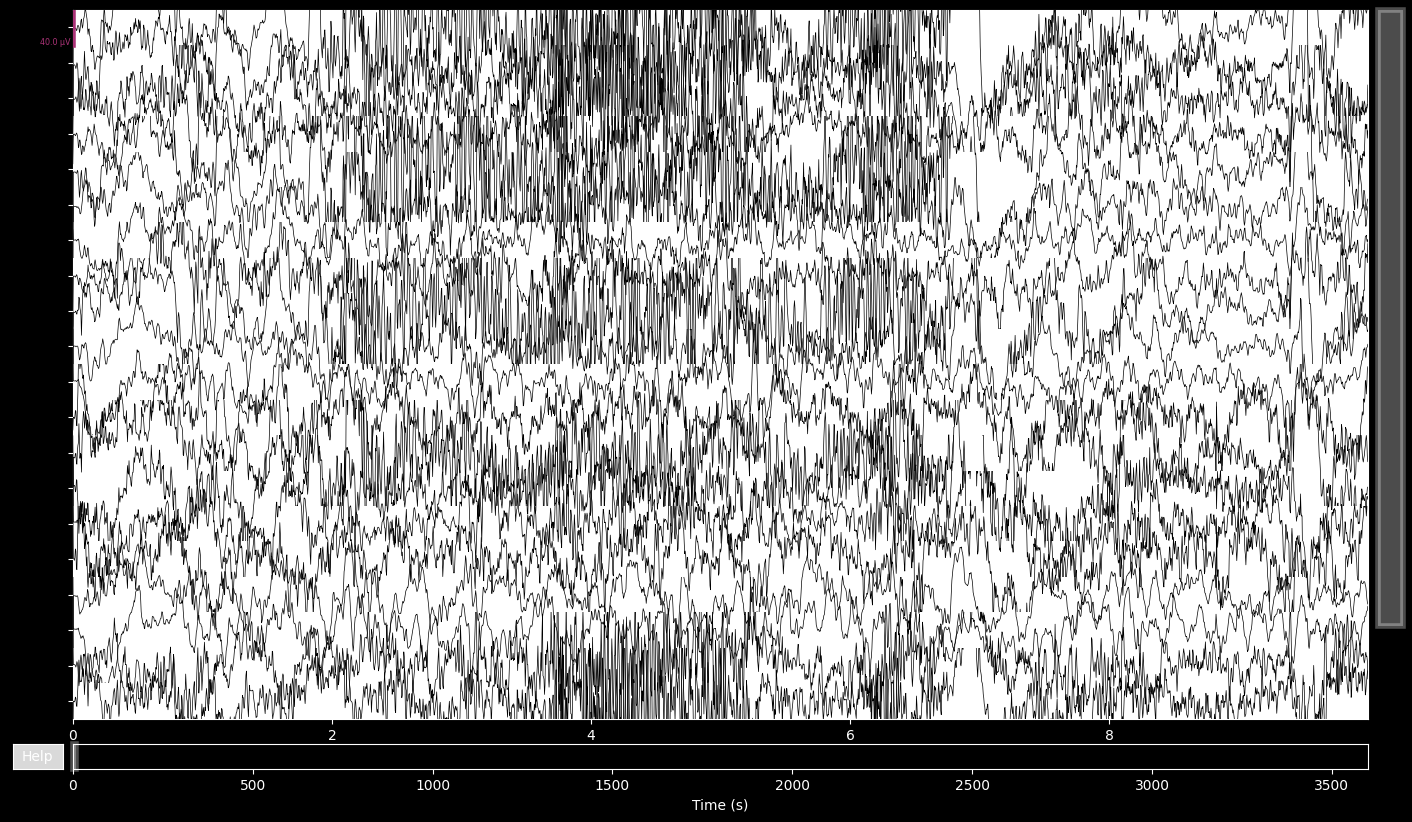

In [39]:
dataset_path = 'data-understanding/data/chb-mit'
raw_folders= deniz.get_folder_names(dataset_path)
raw_paths =deniz.get_edf_paths(dataset_path, raw_folders)
print(raw_paths[0])

raw = mne.io.read_raw_edf(raw_paths[0], preload=False, verbose=False)
raw.plot()


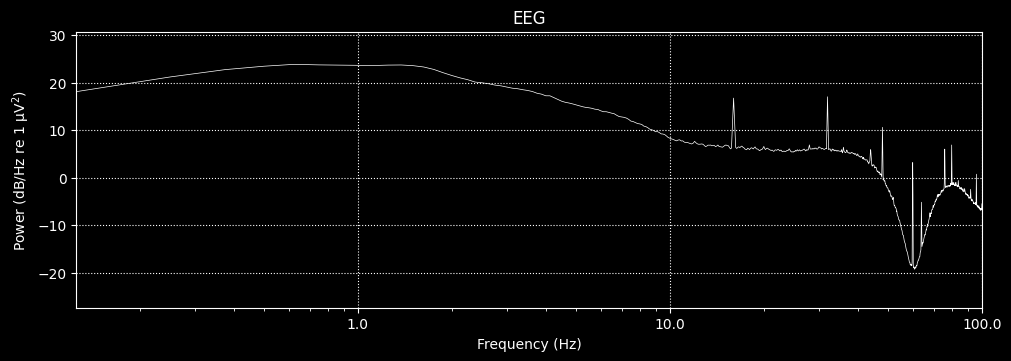

In [40]:
# 1. Compute PSD
spectrum = raw.compute_psd(fmax=100)

# Use the dark_background style context for visibility
with plt.style.context('dark_background'):

    # 2. Plot without averaging (Spatial colors)
    fig1 = spectrum.plot(
        average=False,
        picks="data",
        exclude="bads",
        amplitude=False,
        spatial_colors=True
    )
    # Force figure facecolor to match if it doesn't automatically
    fig1.patch.set_facecolor('white')

    # 3. Plot with averaging and log scale
    fig2 = spectrum.plot(
        average=True,
        xscale="log",
        amplitude=False
    )
    if hasattr(fig2.axes[0], 'get_lines'):
        for line in fig2.axes[0].get_lines():
            line.set_color('white')  # Make the main signal line white

    plt.show()

# After preprocessing

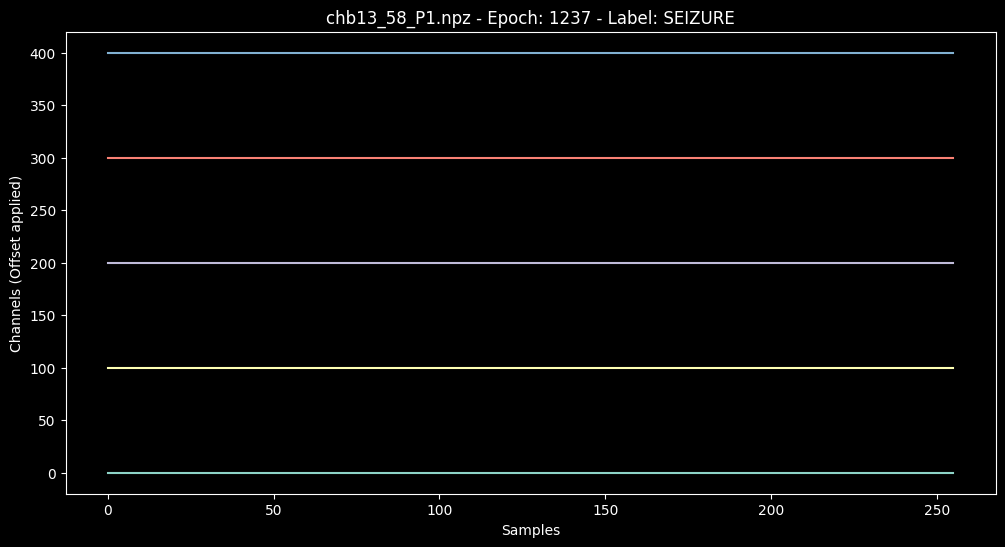

In [41]:
data_path = 'processed_dataset_2'
deniz.verify_processed_data(data_path)

In [42]:
file_path = 'processed_dataset_2/chb10_27_P1.npz'

if os.path.exists(file_path):
    # Load the compressed numpy file
    sample = np.load(file_path)
    X = sample['x']  # EEG Signal
    y = sample['y']  # Label

    print("=" * 40)
    print(f" File Analysis: {os.path.basename(file_path)}")
    print("=" * 40)

    # Display Dimensions
    print(f"🔹 Signal Shape (Channels, Time): {X.shape}")
    print(f"🔹 Class Label: {y}")

    # Logic Check
    # 2 seconds * 128 Hz = 256 samples
    expected_shape = (18, 256)

    if X.shape == expected_shape:
        print(" Dimensions are correct (18 channels, 256 time points).")
    else:
        print(f"️ Unexpected dimensions! Expected {expected_shape}, got {X.shape}")
else:
    print(f" File not found: {file_path}")

 File Analysis: chb10_27_P1.npz
🔹 Signal Shape (Channels, Time): (1800, 18, 256)
🔹 Class Label: [0 0 0 ... 0 0 0]
️ Unexpected dimensions! Expected (18, 256), got (1800, 18, 256)


In [43]:
print(X)

[[[-9.63442846e-08  1.82016780e-05  1.40021911e-05 ... -7.13478956e-05
   -5.02515386e-05 -6.23137597e-05]
  [-1.65156486e-07  2.71711724e-04  2.18944921e-04 ...  3.43027289e-05
    7.29805867e-05  8.77557980e-05]
  [ 1.89106226e-07 -3.85953375e-05 -3.04805059e-05 ...  3.86307936e-05
    4.63718916e-05  6.53446764e-05]
  ...
  [ 2.94026913e-07  9.52705594e-05  7.67667063e-05 ...  1.98737358e-05
    2.60133561e-05  2.15439764e-05]
  [ 5.01695662e-07  1.59574284e-04  1.28493235e-04 ...  5.17637160e-05
    9.96209885e-05  1.48065699e-04]
  [ 1.02841197e-07  1.03842913e-04  8.38797701e-05 ...  9.03605882e-05
    8.17741855e-05  6.57715210e-05]]

 [[-7.93470294e-05 -5.98844104e-05 -5.75119579e-05 ... -1.65674075e-05
    1.55092631e-05  9.42667517e-06]
  [ 9.27223606e-05  1.07991120e-04  1.31780788e-04 ... -1.03719728e-04
   -9.88932720e-05 -9.09605619e-05]
  [ 6.45448281e-05  5.07914440e-05  6.35809097e-05 ...  2.05392557e-05
   -9.43786455e-06 -1.10717545e-05]
  ...
  [ 2.48688896e-05  2.9

In [44]:
print(y)

[0 0 0 ... 0 0 0]


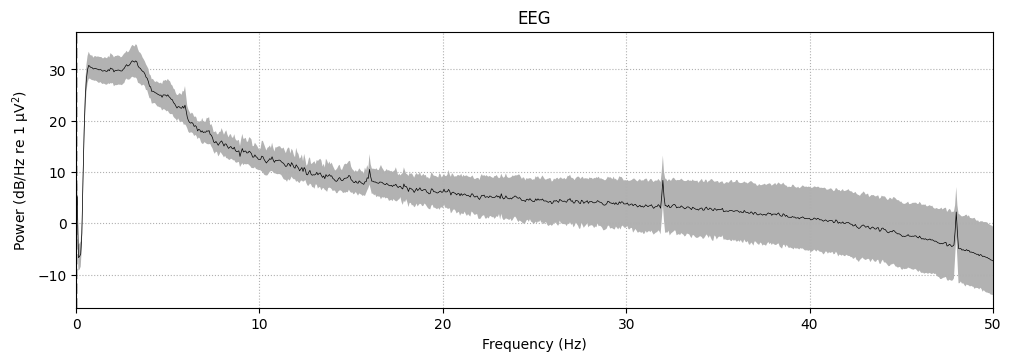

In [47]:
# Use os.path.join to handle the folder correctly
file_path = os.path.join("processed_dataset_2", "chb10_27_P1.npz")

print(f"Loading file from: {file_path}")

try:
    # Load the .npz file
    preprocessed_data = np.load(file_path, allow_pickle=True)

    # 1. Extract the actual data array
    print(f"Keys in file: {preprocessed_data.files}")
    eeg_data = preprocessed_data[preprocessed_data.files[0]]

    print(f"Original Shape: {eeg_data.shape}")
    # Likely (1800, 18, 256) -> (Epochs, Channels, Time)

    # 2. FIX: Convert 3D Epochs to 2D Continuous Data
    if eeg_data.ndim == 3:
        print(" Detected 3D Epoch data. Reshaping to 2D continuous...")

        # Step A: Move Channels to the first dimension
        # Current: (Epochs, Channels, Time) -> Target: (Channels, Epochs, Time)
        eeg_data = np.transpose(eeg_data, (1, 0, 2))

        # Step B: Flatten Epochs and Time into one continuous time dimension
        # Shape becomes: (Channels, Epochs * Time)
        n_channels = eeg_data.shape[0]
        eeg_data = eeg_data.reshape(n_channels, -1)

        print(f" New 2D Shape: {eeg_data.shape}")

    # 3. Define Metadata manually
    sfreq = 128.0  # Assuming 128Hz
    ch_names = [   # Standard CHB-MIT 18 channels
        'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
        'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
        'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
        'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
        'FZ-CZ', 'CZ-PZ'
    ]

    # Create MNE info object
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

    # Create RawArray object (Now receives correct 2D data)
    raw = mne.io.RawArray(eeg_data, info)

    # --- PLOTTING SECTION ---

    # Reset any previous style to default (White)
    plt.style.use('default')

    # 1. Plot Raw Traces
    fig_raw = raw.plot(
        scalings='auto',
        duration=10,
        n_channels=len(ch_names),
        show=False,
        title="Preprocessed EEG (Reshaped from Epochs)",
        color=dict(eeg='black'),
        block=False
    )
    fig_raw.patch.set_facecolor('white')

    # 2. Plot Power Spectral Density (PSD)
    fig_psd = raw.compute_psd(fmax=50).plot(
        average=True,
        spatial_colors=True,
        show=False
    )
    fig_psd.patch.set_facecolor('white')

    # Show all plots
    plt.show()

except FileNotFoundError:
    print(f" Error: Could not find file at '{file_path}'")
except Exception as e:
    print(f" An error occurred: {e}")

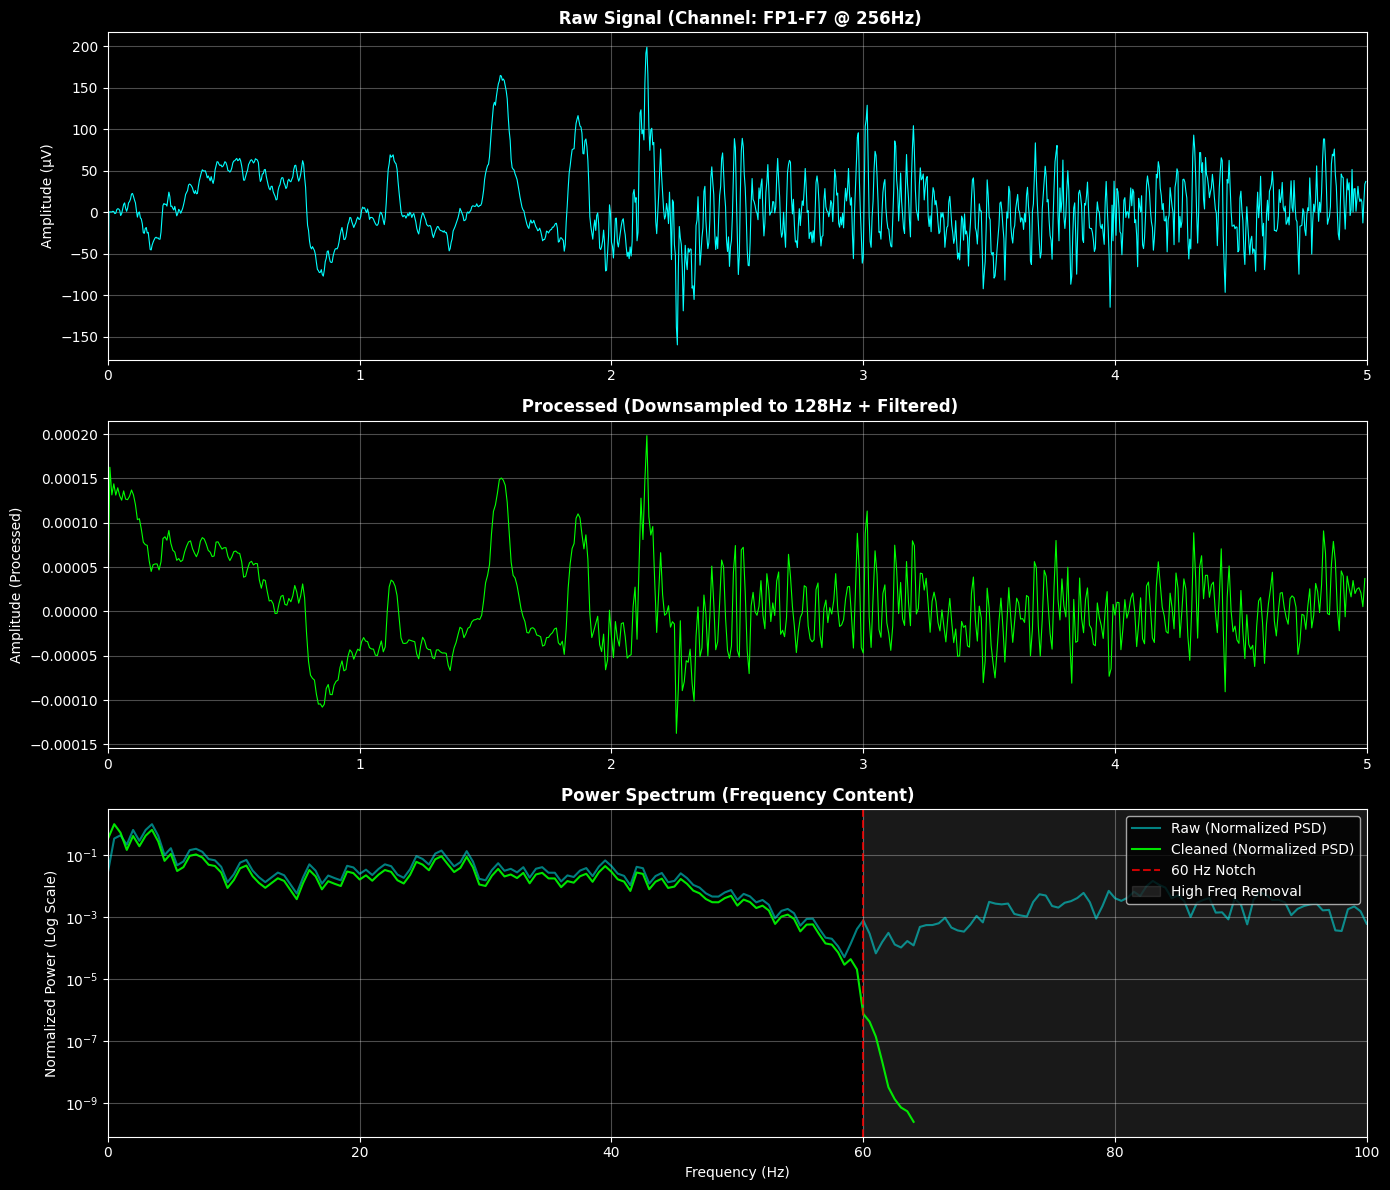

In [46]:
# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ============================================
# 1. SETUP & LOADING
# ============================================
dataset_path = 'data-understanding/data/chb-mit'
subject_folders = deniz.get_folder_names(dataset_path)

FINAL_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ'
]

# Ensure we have data to load
if not subject_folders:
    raise FileNotFoundError(f"No subject folders found in {dataset_path}")

# Get paths for the first subject
edf_paths = deniz.get_edf_paths(dataset_path, subject_folders[0])
file_path = edf_paths[0]
print(f" Loading data from: {file_path}")

# 1. Load using your utility
# Note: Ensure this matches the function name in your my_utils.py
raw = deniz.fix_eeg_channels(file_path, FINAL_CHANNELS)

# 2. Extract info before processing
original_fs = int(raw.info['sfreq'])
print(f"   Original Sampling Rate: {original_fs} Hz")

# Select a specific channel to visualize
channel_name = FINAL_CHANNELS[0]
channel_idx = raw.ch_names.index(channel_name)

# Get 5 seconds of RAW data (converted to µV for readability)
duration_sec = 5
raw_samples = int(duration_sec * original_fs)
raw_signal = raw.get_data(picks=[channel_idx], stop=raw_samples)[0] * 1e6

# ============================================
# 2. DEFINE PREPROCESSING LOGIC
# ============================================

def get_processed_segment(raw_obj, channel_idx, duration_sec):
    # Create a copy to avoid modifying the original 'raw' object
    raw_copy = raw_obj.copy()

    # 1. Downsample
    raw_copy = deniz.downsample(raw_copy)
    new_fs = int(raw_copy.info['sfreq'])

    # 2. Apply Filtering (Bandpass + Notch)
    raw_copy = deniz.apply_filtering(raw_copy)

    # 3. Extract Data
    n_samples = int(duration_sec * new_fs)
    data = raw_copy.get_data(picks=[channel_idx], stop=n_samples)[0]

    return data, new_fs

# Get the processed version
clean_signal, new_fs = get_processed_segment(raw, channel_idx, duration_sec)

# ============================================
# 3. VISUALIZATION
# ============================================

print("="*60)
print(" VISUALIZING PREPROCESSING EFFECT")
print("="*60)

# Time vectors
time_raw = np.arange(len(raw_signal)) / original_fs
time_clean = np.arange(len(clean_signal)) / new_fs

# Apply Dark Background Style
plt.style.use('dark_background')

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Raw Signal
# Using 'cyan' for better visibility on black background
axes[0].plot(time_raw, raw_signal, color='cyan', linewidth=0.8)
axes[0].set_title(f' Raw Signal (Channel: {channel_name} @ {original_fs}Hz)', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration_sec)

# Plot 2: Cleaned Signal
# Using 'lime' (bright green) for contrast
axes[1].plot(time_clean, clean_signal, color='lime', linewidth=0.8)
axes[1].set_title(f' Processed (Downsampled to {new_fs}Hz + Filtered)', fontweight='bold')
axes[1].set_ylabel('Amplitude (Processed)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration_sec)

# Plot 3: Power Spectrum Comparison
freqs_raw, psd_raw = welch(raw_signal, fs=original_fs, nperseg=original_fs*2)
freqs_clean, psd_clean = welch(clean_signal, fs=new_fs, nperseg=new_fs*2)

# Normalize PSD for visual comparison
psd_raw_norm = psd_raw / np.max(psd_raw)
psd_clean_norm = psd_clean / np.max(psd_clean)

axes[2].semilogy(freqs_raw, psd_raw_norm, color='cyan', alpha=0.5, label='Raw (Normalized PSD)', linewidth=1.5)
axes[2].semilogy(freqs_clean, psd_clean_norm, color='lime', alpha=0.9, label='Cleaned (Normalized PSD)', linewidth=1.5)

# Markers for Filter Effects
axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.8, label='60 Hz Notch')
axes[2].axvspan(60, 128, color='white', alpha=0.1, label='High Freq Removal')

axes[2].set_title('Power Spectrum (Frequency Content)', fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Normalized Power (Log Scale)')
axes[2].set_xlim(0, 100)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()

plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show(block=True)

print("\n Preprocessing Effects Observed:")
print(f"   ✓ Sampling Rate: {original_fs}Hz -> {new_fs}Hz")
print("   ✓ High-frequency noise (>60Hz) reduced")
print("   ✓ 60 Hz power line peak removed")

print("\n" + "="*60)
print(" Visualization complete!")
print("="*60)